# Model Validation — Douala & Maroua (Model II)

Visual comparison of **actual GHI** vs **XGBoost predictions** for **both cities** in one notebook.

Run all cells top to bottom.

In [12]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import plot_importance

plt.style.use("seaborn-v0_8-darkgrid")

MODEL_II_FEATURES = [
    "YEAR", "MO", "DY", "HR", "T2M", "RH2M", "PRECTOTCORR", "WS10M",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "day_sin", "day_cos",
    "day_of_year", "is_daytime", "is_rainy", "rain_log1p", "ws10m_log1p",
    "season_dry", "season_rainy",
]
TARGET = "ALLSKY_SFC_SW_DWN"
TEST_HOURS = 168
TRAIN_RATIO = 0.8

CITIES = {
    "douala": {
        "data": "Data/Processed/Douala_Features_Model_II.csv",
        "model": "Model/douala_xgb_model_ii.pkl",
    },
    "maroua": {
        "data": "Data/Processed/Maroua_Features_Model_II.csv",
        "model": "Model/maroua_xgb_model_ii.pkl",
    },
}

def predict_ghi(model, frame: pd.DataFrame) -> np.ndarray:
    return np.clip(model.predict(frame[MODEL_II_FEATURES]), 0, None)

def load_city_validation(city: str) -> dict:
    cfg = CITIES[city]
    df = pd.read_csv(cfg["data"])
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    model_path = Path(cfg["model"])
    if not model_path.exists():
        raise FileNotFoundError(f"Missing {model_path}. Train {city} model first.")

    model = joblib.load(model_path)
    split_idx = int(len(df) * TRAIN_RATIO)
    test_df = df.iloc[split_idx:].copy()
    week_df = df.tail(TEST_HOURS).copy()

    test_df["predicted"] = predict_ghi(model, test_df)
    week_df["predicted"] = predict_ghi(model, week_df)

    return {
        "city": city,
        "df": df,
        "model": model,
        "test_df": test_df,
        "week_df": week_df,
    }

## 1. Load Douala and Maroua

In [13]:
validation = {city: load_city_validation(city) for city in CITIES}

for city, data in validation.items():
    test_df = data["test_df"]
    print(f"\n{city.upper()}")
    print(f"  Rows: {len(data['df']):,}")
    print(f"  Model: {CITIES[city]['model']}")
    print(f"  Date range: {data['df']['datetime'].min()} -> {data['df']['datetime'].max()}")
    print(f"  Holdout: {len(test_df):,} rows")
    print(f"  Actual mean: {test_df[TARGET].mean():.1f} W/m²")
    print(f"  Predicted mean: {test_df['predicted'].mean():.1f} W/m²")


DOUALA
  Rows: 52,584
  Model: Model/douala_xgb_model_ii.pkl
  Date range: 2020-01-01 00:00:00 -> 2025-12-30 23:00:00
  Holdout: 10,517 rows
  Actual mean: 174.5 W/m²
  Predicted mean: 175.1 W/m²

MAROUA
  Rows: 52,584
  Model: Model/maroua_xgb_model_ii.pkl
  Date range: 2020-01-01 00:00:00 -> 2025-12-30 23:00:00
  Holdout: 10,517 rows
  Actual mean: 249.4 W/m²
  Predicted mean: 248.2 W/m²


## 2. Time series — Actual (blue) vs Predicted (orange)

Last 7 days for **each city**.

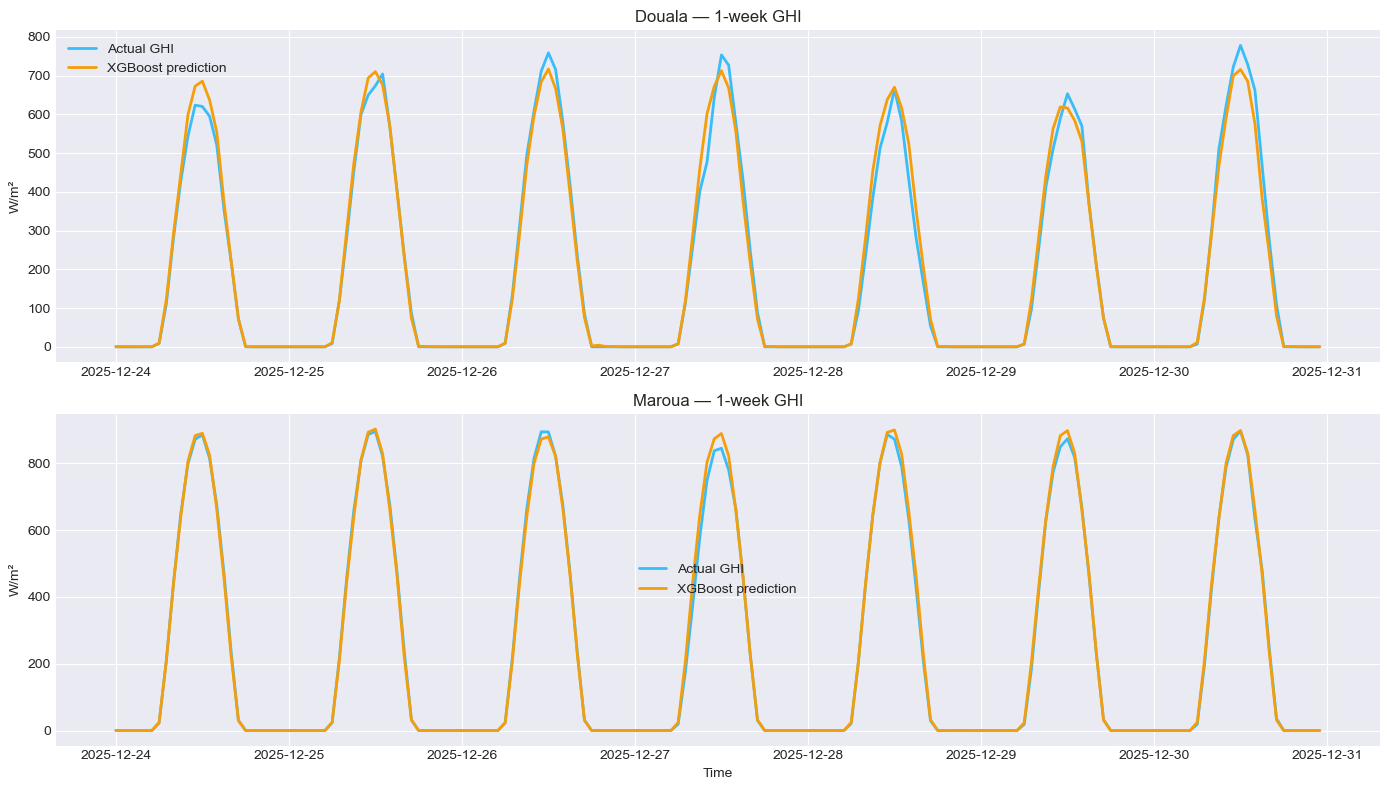

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, city in zip(axes, ["douala", "maroua"]):
    week_df = validation[city]["week_df"]
    ax.plot(week_df["datetime"], week_df[TARGET], label="Actual GHI", color="#38bdf8", linewidth=2)
    ax.plot(week_df["datetime"], week_df["predicted"], label="XGBoost prediction", color="#f59e0b", linewidth=2)
    ax.set_title(f"{city.title()} — 1-week GHI")
    ax.set_ylabel("W/m²")
    ax.legend()

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## 3. Scatter plot — holdout set (last 20%)

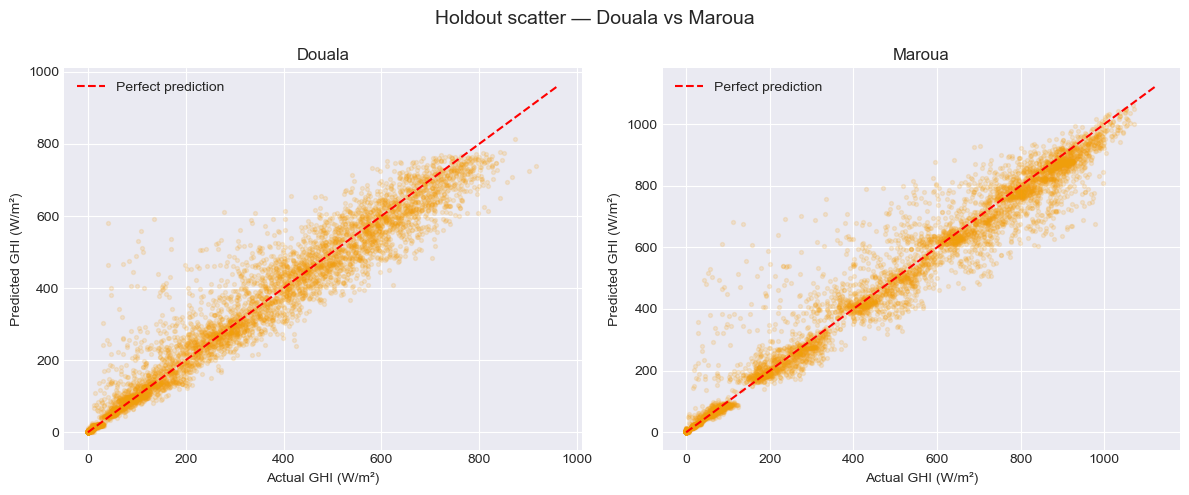

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, city in zip(axes, ["douala", "maroua"]):
    test_df = validation[city]["test_df"]
    y_true = test_df[TARGET]
    y_pred = test_df["predicted"]

    ax.scatter(y_true, y_pred, alpha=0.15, s=8, color="#f59e0b")
    max_val = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
    ax.set_xlabel("Actual GHI (W/m²)")
    ax.set_ylabel("Predicted GHI (W/m²)")
    ax.set_title(city.title())
    ax.legend()

fig.suptitle("Holdout scatter — Douala vs Maroua", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Feature importance

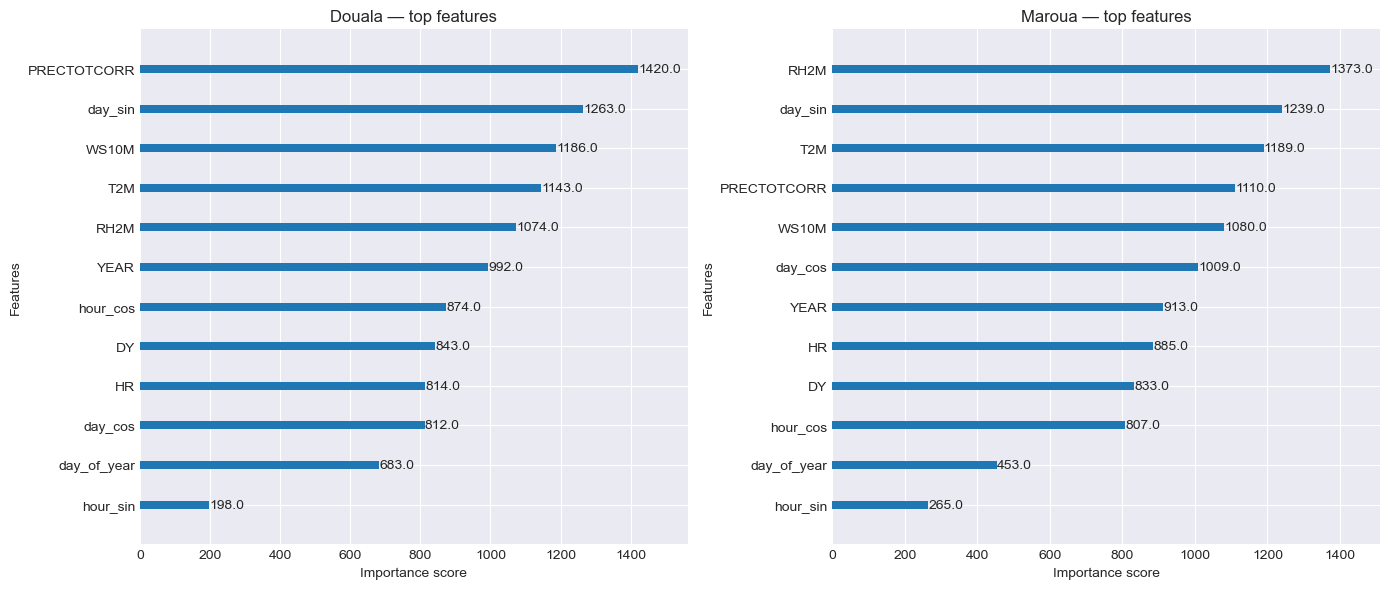

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, city in zip(axes, ["douala", "maroua"]):
    plot_importance(validation[city]["model"], ax=ax, max_num_features=12)
    ax.set_title(f"{city.title()} — top features")

plt.tight_layout()
plt.show()

## 5. Day vs night averages

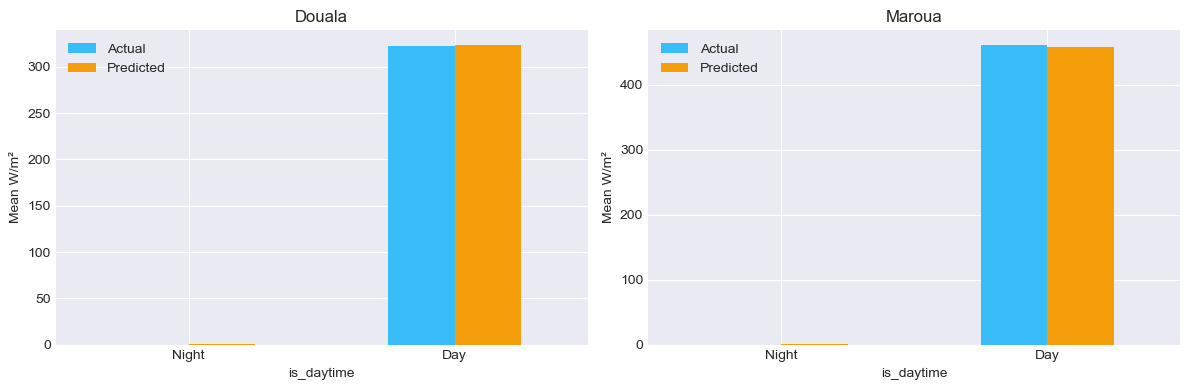

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, city in zip(axes, ["douala", "maroua"]):
    test_df = validation[city]["test_df"]
    daynight = test_df.groupby("is_daytime")[[TARGET, "predicted"]].mean().rename(index={0: "Night", 1: "Day"})
    daynight.plot(kind="bar", ax=ax, color=["#38bdf8", "#f59e0b"], rot=0)
    ax.set_title(city.title())
    ax.set_ylabel("Mean W/m²")
    ax.legend(["Actual", "Predicted"])

plt.tight_layout()
plt.show()

## 6. Dry vs rainy season

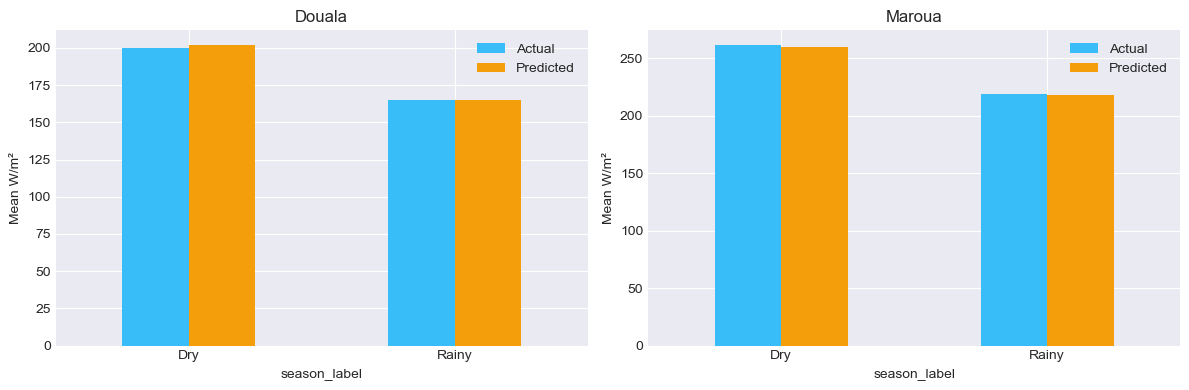

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, city in zip(axes, ["douala", "maroua"]):
    test_df = validation[city]["test_df"].copy()
    test_df["season_label"] = test_df["season_dry"].map({1: "Dry", 0: "Rainy"})
    season_avg = test_df.groupby("season_label")[[TARGET, "predicted"]].mean()
    season_avg.plot(kind="bar", ax=ax, color=["#38bdf8", "#f59e0b"], rot=0)
    ax.set_title(city.title())
    ax.set_ylabel("Mean W/m²")
    ax.legend(["Actual", "Predicted"])

plt.tight_layout()
plt.show()

## 7. Average diurnal profile (by hour)

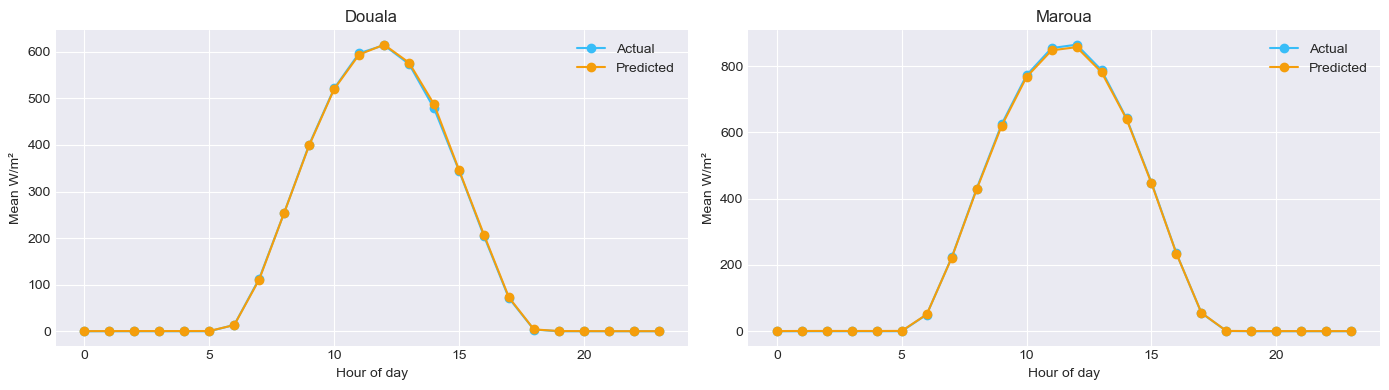

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, city in zip(axes, ["douala", "maroua"]):
    hourly = validation[city]["test_df"].groupby("HR")[[TARGET, "predicted"]].mean()
    ax.plot(hourly.index, hourly[TARGET], marker="o", label="Actual", color="#38bdf8")
    ax.plot(hourly.index, hourly["predicted"], marker="o", label="Predicted", color="#f59e0b")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean W/m²")
    ax.set_title(city.title())
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Spot-check tables (10 random hours each)

In [20]:
for city in ["douala", "maroua"]:
    sample = validation[city]["test_df"].sample(10, random_state=42)[
        ["datetime", TARGET, "predicted", "T2M", "RH2M", "PRECTOTCORR", "is_daytime"]
    ].copy()
    sample["error"] = (sample[TARGET] - sample["predicted"]).round(1)
    sample = sample.rename(columns={TARGET: "actual"})
    print(f"\n{city.upper()} — random spot checks")
    display(sample)


DOUALA — random spot checks


,datetime,actual,predicted,T2M,RH2M,PRECTOTCORR,is_daytime,error
50682,2025-10-12 18:00:00,0.00,0.000000,27.61,84.38,3.33,1,0.0
51740,2025-11-25 20:00:00,0.00,0.000000,25.91,94.34,0.49,0,0.0
52431,2025-12-24 15:00:00,353.62,373.641357,32.35,51.53,0.18,1,-20.0
47558,2025-06-04 14:00:00,482.38,429.743439,27.80,80.04,25.45,1,52.6
45753,2025-03-21 09:00:00,394.98,402.520569,28.08,79.20,7.35,1,-7.5
50411,2025-10-01 11:00:00,459.30,500.782196,27.34,72.38,11.62,1,-41.5
50620,2025-10-10 04:00:00,0.00,0.000000,23.84,94.23,6.21,0,0.0
46528,2025-04-22 16:00:00,246.98,234.572037,30.00,74.40,3.78,1,12.4
49211,2025-08-12 11:00:00,407.10,459.782898,29.16,66.58,3.72,1,-52.7
42378,2024-10-31 18:00:00,0.00,0.428532,24.49,97.32,9.62,1,-0.4



MAROUA — random spot checks


,datetime,actual,predicted,T2M,RH2M,PRECTOTCORR,is_daytime,error
50682,2025-10-12 18:00:00,0.00,1.771398,25.82,79.07,0.02,1,-1.8
51740,2025-11-25 20:00:00,0.00,0.000000,27.56,28.39,0.00,0,0.0
52431,2025-12-24 15:00:00,470.10,456.730621,36.97,8.49,0.00,1,13.4
47558,2025-06-04 14:00:00,756.83,676.177734,39.25,24.36,0.02,1,80.7
45753,2025-03-21 09:00:00,726.65,640.744263,35.13,8.83,0.00,1,85.9
50411,2025-10-01 11:00:00,949.42,889.428223,28.57,73.01,2.21,1,60.0
50620,2025-10-10 04:00:00,0.00,2.218719,22.56,87.57,0.00,0,-2.2
46528,2025-04-22 16:00:00,313.77,299.513824,41.77,8.13,0.00,1,14.3
49211,2025-08-12 11:00:00,748.47,728.446899,29.84,64.20,12.91,1,20.0
42378,2024-10-31 18:00:00,0.00,0.000000,24.95,56.29,0.00,1,0.0


## 9. Summary comparison table

In [ ]:
rows = []
for city in ["douala", "maroua"]:
    test_df = validation[city]["test_df"]
    y_true = test_df[TARGET]
    y_pred = test_df["predicted"]
    rows.append({
        "city": city.title(),
        "holdout_rows": len(test_df),
        "actual_mean_wm2": round(y_true.mean(), 1),
        "predicted_mean_wm2": round(y_pred.mean(), 1),
        "night_actual_mean": round(test_df.loc[test_df["is_daytime"] == 0, TARGET].mean(), 1),
        "night_pred_mean": round(test_df.loc[test_df["is_daytime"] == 0, "predicted"].mean(), 1),
        "day_actual_mean": round(test_df.loc[test_df["is_daytime"] == 1, TARGET].mean(), 1),
        "day_pred_mean": round(test_df.loc[test_df["is_daytime"] == 1, "predicted"].mean(), 1),
    })

summary = pd.DataFrame(rows)
display(summary)

,city,holdout_rows,actual_mean_wm2,predicted_mean_wm2,night_actual_mean,night_pred_mean,day_actual_mean,day_pred_mean
0,Douala,10517,174.5,175.100006,0.0,0.4,322.3,323.200012
1,Maroua,10517,249.4,248.199997,0.0,0.7,460.7,457.799988


: 

---
### How to read results

| Check | Good sign | Bad sign |
|-------|-----------|----------|
| Time series | Orange follows blue | Flat or random orange line |
| Scatter | Points near red diagonal | Wide cloud far from diagonal |
| Night | Both near 0 W/m² | High predictions at night |
| Diurnal curve | Peaks at midday | Wrong peak time |
| Maroua vs Douala | Maroua often higher GHI (dry north) | Same pattern for both cities would be suspicious |